#### 1. Borjar med att importera biblioteken Pandas och matplotlib, som jag forst installerat med python -m pip install i terminalen

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### 1b. `df.shape()`: Den här funktionen används för att förstå antalet rader (observationer) och kolumner (features/variabler) i datasetet. Det ger en översikt över datasetets storlek och struktur.


In [45]:
df.shape # Visar antal rader och kolumner

(20640, 10)

#### 2. Borjar nu med att granska struktur och innehall i mitt data-set med grundlaggande inspektionskommandon: 

In [46]:
# Kollar hur många saknade värden som finns per kolumn
print(df.isnull().sum()) 


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


**Ovan ser vi att vi har 207 saknade varden av total_bedrooms, vi loser detta langre ner - Åtgärder inför modellering**

In [47]:

df.info() # Ger en teknisk sammanfattning och identifierar datatyper

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [48]:
df.describe() # Visar statistik som medelvärde, min, max och standardavvikelse för alla numeriska kolumner


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### 3. Utforska den kategoriska datan 
Datasetet innehåller en tydlig kategorisk variabel, ocean_proximity, som anger hur nära havet bostaden ligger. 
Utifrån källdatan ser vi att kolumnen innehåller värden som "NEAR BAY", "INLAND", "<1H OCEAN", "NEAR OCEAN" och "ISLAND". 
Du undersöker fördelningen enklast så här:


In [52]:
print(df['ocean_proximity'].value_counts())


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Se forsta grafen nedan, standard median house values, har ser man hur den sista stapeln ar markligt hog, med valdigt hog frequency, sa fragan ar forstas om detta ar en outlier?

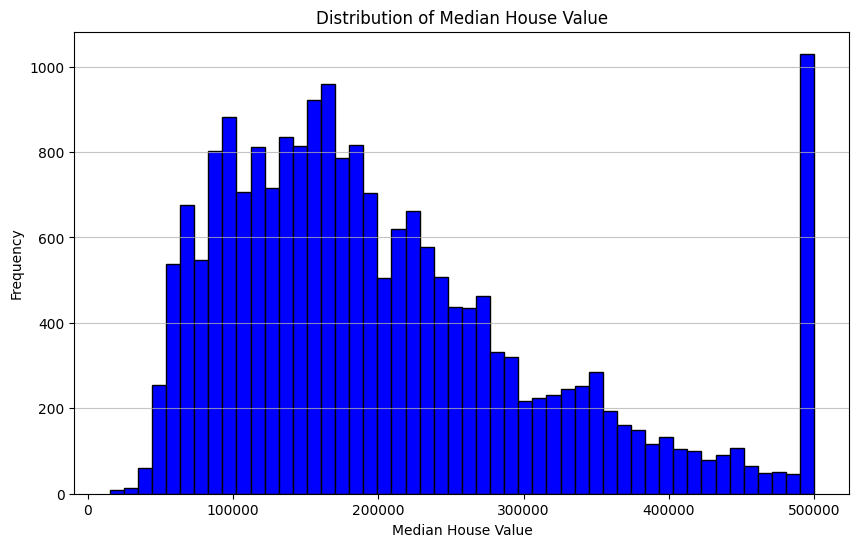

In [53]:
plt.figure(figsize=(10, 6))
plt.hist(df['median_house_value'], bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### 4. Visualisera geografiska data och priser
 **Eftersom dataset:et innehåller koordinater i form av longitude och latitude passar det perfekt för att plotta ut alla datapunkter som en karta. 
 Genom att färgkoda punkterna efter medianvärdet på husen (median_house_value) kan man snabbt se vilka geografiska områden (exempelvis kustområden gentemot inlandet) som är dyrast.**

Note: you may need to restart the kernel to use updated packages.


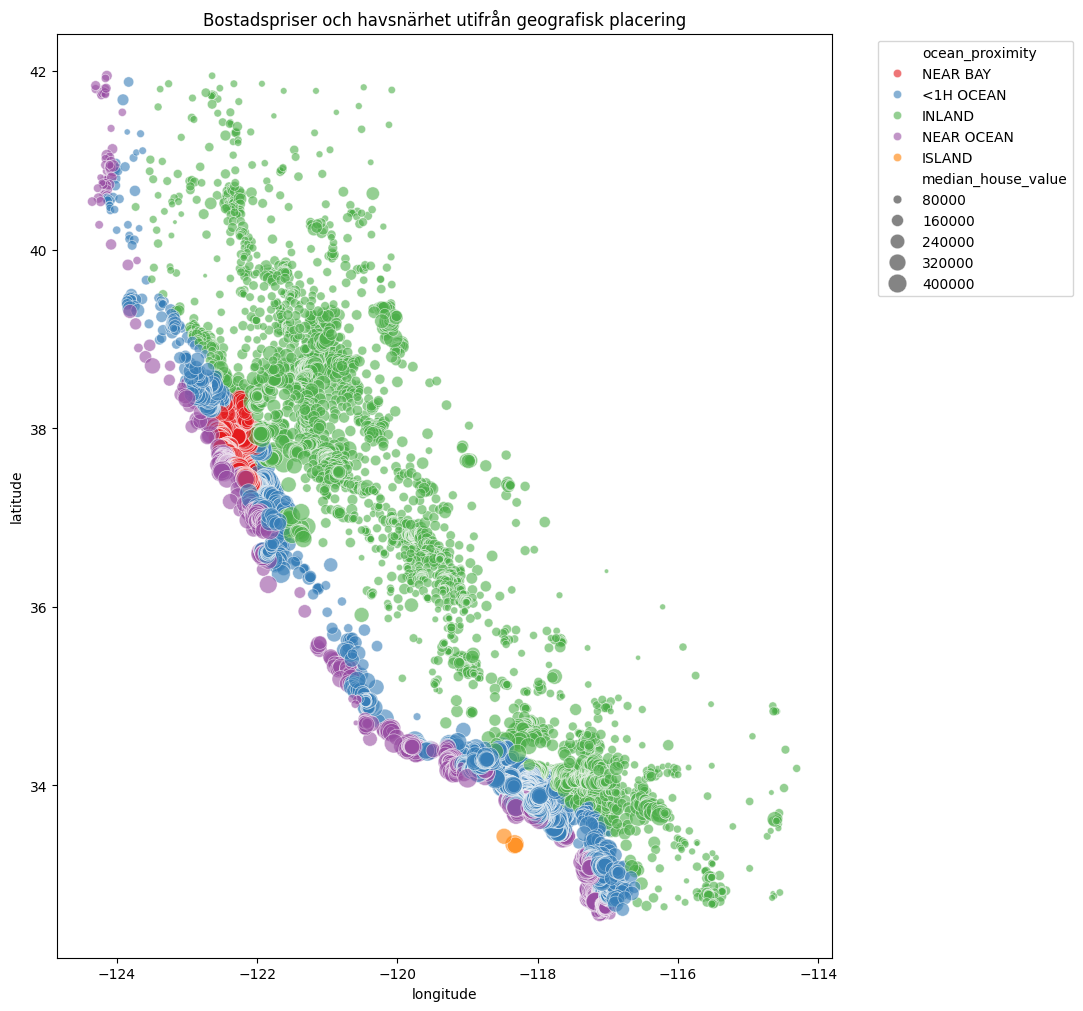

In [77]:
# install seaborn if missing and import it
%pip install seaborn
import seaborn as sns

# Recreate the original ocean_proximity category after one-hot encoding
if 'ocean_proximity' not in df.columns:
	prox_cols = [col for col in df.columns if col.startswith('ocean_proximity_')]
	df['ocean_proximity'] = df[prox_cols].idxmax(axis=1).str.replace('ocean_proximity_', '')

plt.figure(figsize=(10, 12))
sns.scatterplot(
	x='longitude',
	y='latitude',
	data=df,
	hue='ocean_proximity',
	size='median_house_value',
	sizes=(10, 200),
	palette='Set1',
	alpha=0.6
)
plt.title('Bostadspriser och havsnärhet utifrån geografisk placering')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Flyttar ut förklaringen
plt.show()

#### 4b Det bästa diagrammet för prisjämförelse: 
**Boxplot (Låddiagram)
Om huvudsyftet med EDA:n är att faktiskt jämföra hur mycket ocean_proximity påverkar priset, blir en karta ofta lite plottrig. Då är det bästa diagrammet en Boxplot. Det skippar koordinaterna helt och visar istället spridningen, snittpriserna och extremvärdena för bostäder i "INLAND" jämfört med exempelvis "ISLAND".**


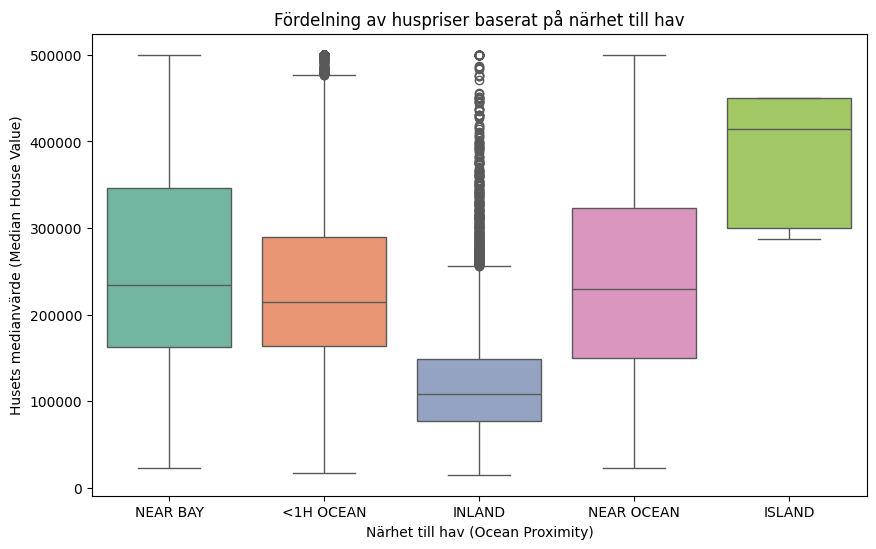

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='ocean_proximity', 
    y='median_house_value', 
    data=df,
    palette='Set2', hue='ocean_proximity', dodge=False
)
plt.title('Fördelning av huspriser baserat på närhet till hav')
plt.xlabel('Närhet till hav (Ocean Proximity)')
plt.ylabel('Husets medianvärde (Median House Value)')
plt.show()

#### 4c Hur hittar vi vara outliers? Och vad gor vi? 
**Mha av vara grafer bl a ser vi tydligt att vi har outliers, dessa fixar vi i nasta steg**

### Åtgärder inför modellering
* Filtrera bort takvärden: 
Innan man tränar en modell måste man ta bort alla rader där huspriset är exakt 500001.0. Om dessa behålls kommer modellen att misstolka datan och lära sig en onaturlig maxspärr.
* Imputering av saknade sovrum: 
De rader som saknar uppgifter om antal sovrum måste hanteras för att modellen inte ska krascha. Vi kan forsoka med det vanligaste sättet att ersätta de tomma fälten med kolumnens totala medianvärde.
* Feature Engineering (Skapa nya variabler): 
Använd källdatans kolumner för att skapa de tre nya ratio-variablerna: rum per hushåll, sovrum per rum och befolkning per hushåll
* Filtrera ut outliers: 
Efter man städat bort de artificiella takvärdena bör IQR-metoden (Interquartile Range) koras för att identifiera faktiska extrema avvikelser i priser och inkomster.
* Numerisk konvertering (Encoding): 
 Maskininlärningsmodeller förstår enbart numerisk data. Därför måste alla textkategorier (exempelvis "INLAND" och "NEAR OCEAN") först omvandlas till numeriska format via metoder som One-Hot Encoding eller dummy-variabler innan träningsfasen inleds.

**Steg 1 adresserar det onaturliga maxvärdet. I din fil kan vi se många extremt dyra hus som har stämplats med exakt 500001.0, vilket skulle förstöra modellens träning.**

In [60]:
# --- 1. Filtrera bort takvärden ---
# Tar bort alla rader där huspriset har registrerats som exakt 500001.0
df = df[df['median_house_value'] != 500001.0]

**Och har dubbelkollar vi att det inte finns nagot felaktigt takvarde kvar**

In [61]:
# Letar specifikt efter det felaktiga takvärdet och räknar antalet träffar
kvarvarande = len(df[df['median_house_value'] == 500001.0])
print(f"Antal hus med värdet 500001.0 kvar i datan: {kvarvarande}")

Antal hus med värdet 500001.0 kvar i datan: 0


**Steg 2 löser problemet med saknad data. I källdatan utelämnas ibland antalet sovrum helt (exempelvis syns det som två kommatecken i rad: 992.0,,732.0), och Pandas behöver ett faktiskt värde där för att maskininlärningsmodellerna inte ska krascha**

In [62]:
# --- 2. Imputering av saknade sovrum --det finns 207 saknade värden i total_bedrooms ---

# Räknar ut medianen
median_bedrooms = df['total_bedrooms'].median()

# Skriver över kolumnen istället för att använda inplace=True
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

**Nu testar vi detta**

In [63]:
# Kollar hur många saknade värden som finns per kolumn
print(df.isnull().sum()) 


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


**I Steg 3 gör koden dataprepareringen mycket mer robust. Eftersom källdatan innehåller rena klumpsummor för bland annat totalt antal rum (total_rooms), sovrum (total_bedrooms), befolkning (population) och hushåll (households), hjälper dessa nya ratio-kolumner modellen att förstå datan proportionerligt istället för bara i absoluta tal**

In [75]:
# --- 3. Feature Engineering (Skapa ratio-kolumner) ---
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

**Nu testar vi detta nedan**

In [72]:
# Titta på källdatan och dina tre nya ratio-kolumner sida vid sida
print(df[['total_rooms', 'households', 'total_bedrooms', 'population', 
          'rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

   total_rooms  households  total_bedrooms  population  rooms_per_household  \
1       7099.0      1138.0          1106.0      2401.0             6.238137   
2       1467.0       177.0           190.0       496.0             8.288136   
3       1274.0       219.0           235.0       558.0             5.817352   
4       1627.0       259.0           280.0       565.0             6.281853   
5        919.0       193.0           213.0       413.0             4.761658   

   bedrooms_per_room  population_per_household  
1           0.155797                  2.109842  
2           0.129516                  2.802260  
3           0.184458                  2.547945  
4           0.172096                  2.181467  
5           0.231774                  2.139896  


**I Steg 4 gör koden den så kallade IQR-metoden (Interquartile Range) för att matematiskt identifiera och filtrera bort outliers (extrema avvikelser) i kolumnen för huspriser (median_house_value).**

In [64]:
# --- 3. Filtrera ut outliers (IQR-metoden på huspriser) ---
# Beräknar gränser för vad som är extrema huspriser och behåller bara normala värden
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1
nedre_grans = Q1 - 1.5 * IQR
ovre_grans = Q3 + 1.5 * IQR

# Sparar över df med enbart de rader som ligger INNANFÖR gränserna
df = df[(df['median_house_value'] >= nedre_grans) & (df['median_house_value'] <= ovre_grans)]


**Nu testar vi detta**

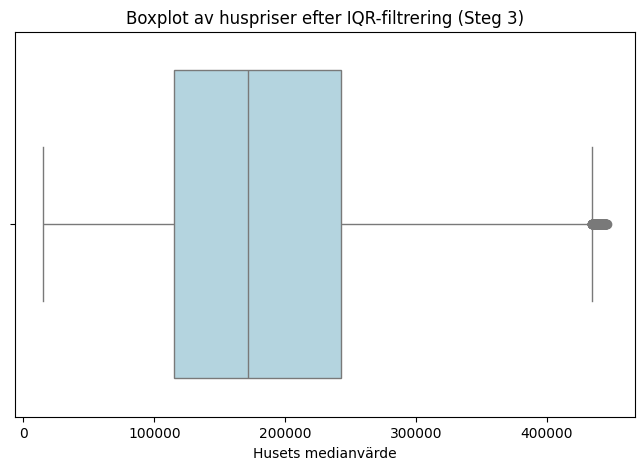

In [65]:
plt.figure(figsize=(8, 5))
# Ritar ett boxplot för alla huspriser
sns.boxplot(x=df['median_house_value'], color='lightblue')
plt.title('Boxplot av huspriser efter IQR-filtrering (Steg 3)')
plt.xlabel('Husets medianvärde')
plt.show()

**Steg 4 är avgorande eftersom modeller inte kan läsa ord. Koden tar kategorierna i kolumnen ocean_proximity ("NEAR BAY", "INLAND", "NEAR OCEAN", "<1H OCEAN" och "ISLAND") och skapar en ny kolumn för varje. Om ett hus ligger i inlandet kommer kolumnen ocean_proximity_INLAND att få en etta (1), och de andra fyra kolumnerna får en nolla (0).**

In [67]:

# --- 4. Numerisk konvertering (One-Hot Encoding) ---
# Gör om textkategorierna för havsnärhet till binära kolumner (1 eller 0)
df = pd.get_dummies(df, columns=['ocean_proximity'])

**För att verifiera att Steg 4 (One-Hot Encoding) har fungerat korrekt vill vi bevisa två saker: att den gamla textkolumnen ocean_proximity är borta, och att den har ersatts av fem nya numeriska kolumner (en för varje geografisk kategori).**

In [68]:
# Skriver ut en lista på alla dina kolumnnamn
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='str')


In [69]:
# Titta på de första 5 raderna i hela tabellen
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,False,False,False,True,False


In [70]:
df.info() # Ger en teknisk sammanfattning och identifierar datatyper

<class 'pandas.DataFrame'>
Index: 19324 entries, 1 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   19324 non-null  float64
 1   latitude                    19324 non-null  float64
 2   housing_median_age          19324 non-null  float64
 3   total_rooms                 19324 non-null  float64
 4   total_bedrooms              19324 non-null  float64
 5   population                  19324 non-null  float64
 6   households                  19324 non-null  float64
 7   median_income               19324 non-null  float64
 8   median_house_value          19324 non-null  float64
 9   ocean_proximity_<1H OCEAN   19324 non-null  bool   
 10  ocean_proximity_INLAND      19324 non-null  bool   
 11  ocean_proximity_ISLAND      19324 non-null  bool   
 12  ocean_proximity_NEAR BAY    19324 non-null  bool   
 13  ocean_proximity_NEAR OCEAN  19324 non-null  boo

#### Nu har vi kollat att det blivit bool istallet for str, sa nu har vi masserat datan infor modellering.

In [80]:
plt.figure(figsize=(12, 10))

# Beräknar korrelationen mellan numeriska kolumner
correlation_matrix = df.select_dtypes(include='number').corr()

# Skapar själva heatmapen
# annot=True skriver ut de exakta decimaltalen i varje ruta
# cmap='coolwarm' ger en tydlig färgskala från blått (negativt) till rött (positivt)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Korrelations-heatmap över bostadsmarknaden')
plt.show()

ValueError: could not convert string to float: 'NEAR BAY'

<Figure size 1200x1000 with 0 Axes>